\# IBM HR Employee Attrition — Notebook 3: Driver Analysis

\#\# Goal

The descriptive analysis \(Notebook 2\) showed where attrition is concentrated
across individual variables — but it can't tell us which variables are
\*genuinely driving\* attrition vs\. which are merely correlated with another
variable that's the real driver\.

For example: lower\-paid employees attrite more, AND lower\-paid employees
tend to be at the entry level\. Is pay the driver? Or career stage? Or both?
A single\-variable table can't answer that\.

This notebook uses two methods to identify true drivers:

1\. \*\*Random Forest with permutation importance\*\* — ranks how much each
   variable contributes to predicting attrition while controlling for
   all the others
2\. \*\*Variance Inflation Factor \(VIF\) \+ correlation matrix\*\* — flags
   variables that are statistical duplicates of each other so we don't
   double\-count the same signal

This mirrors \*\*Section 4\*\* of the methodology report\.

\#\# Why this is the meatiest notebook

The path to the final 5 variables involves several decisions that
matter for any future analyst trying to reproduce the work:

\- Which variables get excluded \*before\* modeling and why \(Section 4\.1\)
\- How to read MDI feature importance and why it can mislead \(Section 4\.2\)
\- Why permutation importance with F1 scoring is the right validator
  \(Section 4\.3\)
\- How to handle the career\-stage cluster of correlated variables \(Section 4\.4\)

Each of these is its own section below\.

In [3]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 38.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# sklearn provides the Random Forest, train/test split, and permutation tools
# statsmodels provides the VIF function — sklearn doesn't include it
# matplotlib + seaborn for the correlation heatmaps and importance bar chart

\#\# Section 4\.1 — Data Preparation for Modeling

Before training any model, we have to decide which columns to feed it
and which to drop\. Six categories of exclusion:

\| Category \| Columns \| Why \|
\|\-\-\-\|\-\-\-\|\-\-\-\|
\| Constants \| \`EmployeeCount\`, \`StandardHours\`, \`Over18\` \| Same value for every row → zero predictive power \|
\| Identifier \| \`EmployeeNumber\` \| Unique ID — would just memorize each employee \|
\| Text target \| \`Attrition\` \| We use the binary \`Attrition\_Flag\` instead \|
\| Protected attributes \| \`Age\`, \`Gender\` \| Legal risk \+ correlation analysis showed Age = 0\.68 with TotalWorkingYears \(proxy for career stage\) and Gender = 0\.00 with attrition \|
\| Low\-signal categorical \| \`MaritalStatus\` \| Multi\-category, exploratory analysis showed no validated signal \|
\| Multi\-category not yet encoded \| \`Department\`, \`JobRole\`, \`EducationField\` \| Could be one\-hot encoded but each adds many columns and Section 3 showed these are surface symptoms, not drivers \|
\| Original travel column \| \`BusinessTravel\` \| Replaced by ordinal numeric encoding \`BusinessTravel\_Num\` \|

Note on \`Age\`: the methodology excludes Age both because it's a protected
characteristic under ADEA \*and\* because it's a strong proxy for career
stage\. If we kept it, it would absorb signal that we want attributed
to JobLevel / TotalWorkingYears\.

In [7]:
# Build target and binary encodings
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime']       = (df['OverTime']  == 'Yes').astype(int)

# BusinessTravel has a natural order — encode as ordinal numeric
df['BusinessTravel_Num'] = df['BusinessTravel'].map({
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
})
                # ordinal encoding preserves the natural ordering
                # (more travel > less travel) which a tree can use cleanly
                # without inflating the column count via one-hot encoding

# Define the exclusions
drop_cols = [
    'EmployeeCount', 'StandardHours', 'Over18',         # constants
    'EmployeeNumber',                                    # identifier
    'Attrition',                                         # text target
    'Age', 'Gender', 'MaritalStatus',                    # excluded by design
    'Department', 'JobRole', 'EducationField',           # multi-category
    'BusinessTravel',                                    # replaced by numeric
]

# Build the feature list — everything that's not dropped and not the target
feature_cols = [c for c in df.columns
                if c not in drop_cols
                and c != 'Attrition_Flag']

X = df[feature_cols]
y = df['Attrition_Flag']

print(f"Features going into RF ({len(feature_cols)} total):\n")
for c in feature_cols:
    print(f"  - {c}")
print(f"\nAttrition rate: {y.mean():.3f}")

Features going into RF (24 total):

  - DailyRate
  - DistanceFromHome
  - Education
  - EnvironmentSatisfaction
  - HourlyRate
  - JobInvolvement
  - JobLevel
  - JobSatisfaction
  - MonthlyIncome
  - MonthlyRate
  - NumCompaniesWorked
  - OverTime
  - PercentSalaryHike
  - PerformanceRating
  - RelationshipSatisfaction
  - StockOptionLevel
  - TotalWorkingYears
  - TrainingTimesLastYear
  - WorkLifeBalance
  - YearsAtCompany
  - YearsInCurrentRole
  - YearsSinceLastPromotion
  - YearsWithCurrManager
  - BusinessTravel_Num

Attrition rate: 0.161


\#\# Reference — Full Correlation Matrix

Before doing any feature importance ranking, it's useful to look at
the full correlation matrix one time\. This serves two purposes:

1\. \*\*Spot synthetic artifacts\.\*\* Variables that correlate at exactly
   0\.00 with everything else are suspicious — they're likely random
   noise inserted into the dataset rather than meaningful signals\.
   \`DailyRate\`, \`HourlyRate\`, and \`MonthlyRate\` show this pattern\.

2\. \*\*Spot collinearity clusters\.\*\* Groups of variables that all
   correlate strongly with each other \(e\.g\. JobLevel ↔ MonthlyIncome
   ↔ TotalWorkingYears ↔ YearsAtCompany\) form what statisticians
   call a multicollinearity cluster — they're measuring the same
   underlying thing \(career stage\) in slightly different ways\.
   Section 4\.4 will deal with this directly\.

This is just a reference visualization — not a step in the variable
selection process\.

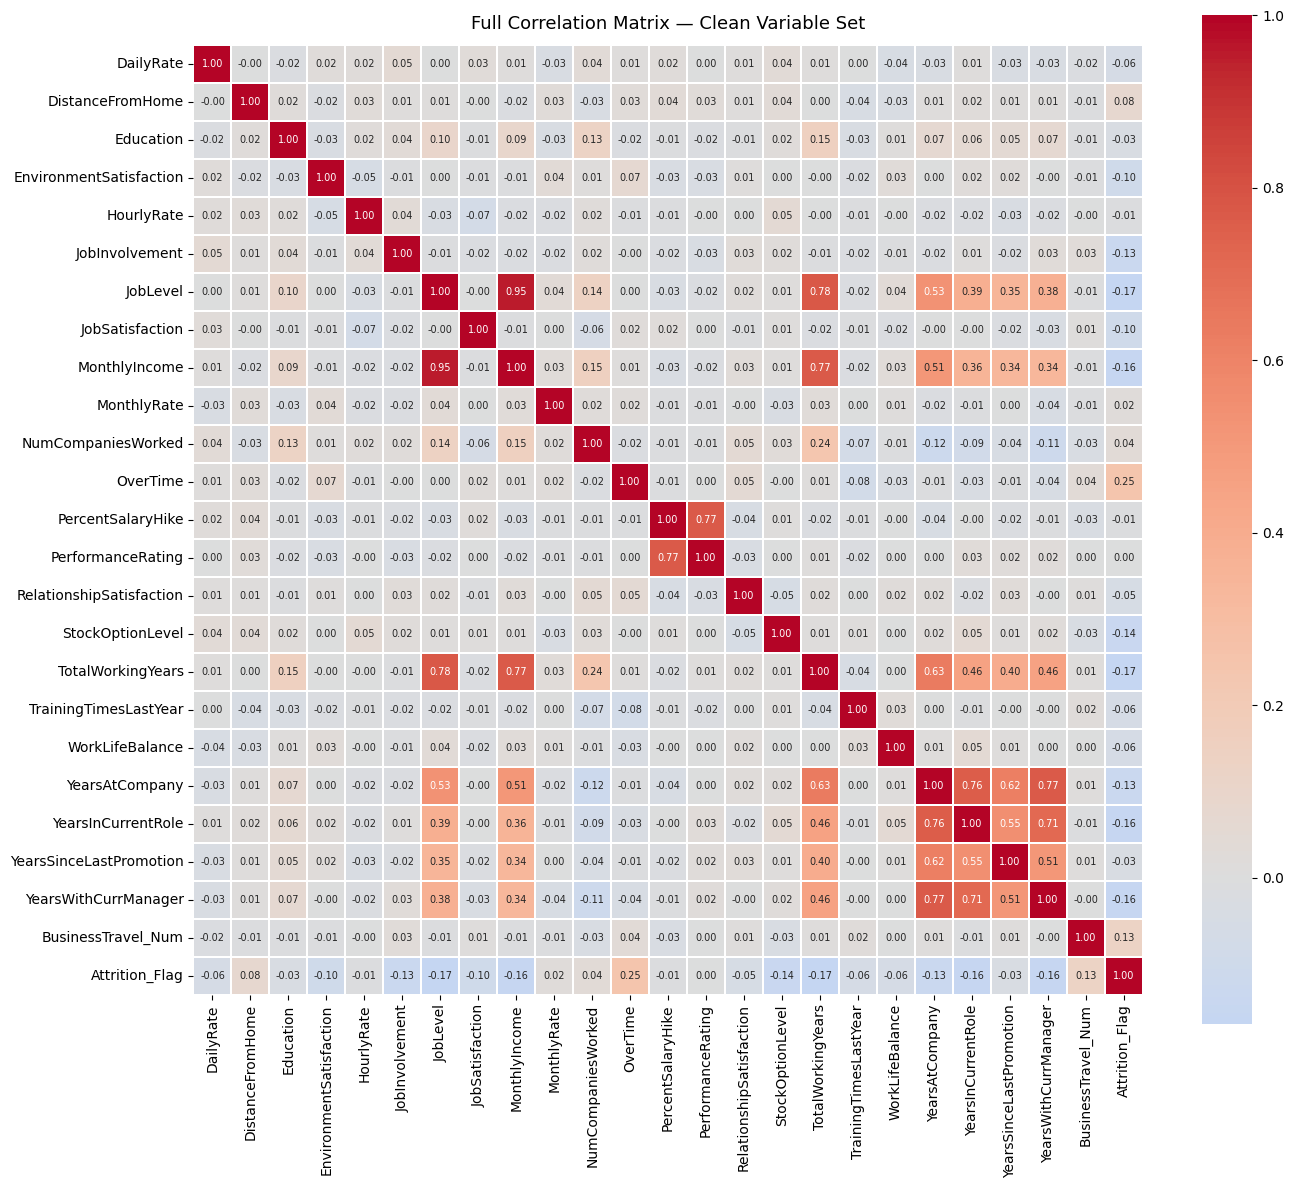

In [9]:
# Reference: full correlation matrix on the clean feature set
# Includes Attrition_Flag so we can see correlation with the target

corr_df = df[feature_cols + ['Attrition_Flag']].corr().round(2)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_df,
    annot=True,                 # show numbers in each cell
    fmt='.2f',                  # 2 decimal places
    cmap='coolwarm',            # blue=negative, red=positive
    center=0,                   # white = zero correlation
    square=True,                # square cells
    linewidths=0.3,             # thin lines between cells
    annot_kws={"size": 7}       # smaller text since there are many cells
)
plt.title('Full Correlation Matrix — Clean Variable Set',
          fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR:
# - The Attrition_Flag row/column shows correlations with the target.
#   Anything above 0.15 absolute value is a candidate variable.
# - The career stage cluster (JobLevel, MonthlyIncome, TotalWorkingYears,
#   YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager) all
#   correlate with each other in the 0.34-0.95 range — this is the
#   collinearity issue we'll address in Section 4.4.
# - DailyRate, HourlyRate, MonthlyRate all near 0.00 with everything —
#   likely synthetic artifacts. Track whether they show up high in
#   MDI but low in permutation (a tell that MDI is being fooled).
# - OverTime correlates with Attrition_Flag at r=0.25 — the strongest
#   single attrition predictor in the dataset.

\#\# Section 4\.2 — Random Forest with Class Balancing

A Random Forest builds many decision trees on different random slices
of the data and averages their predictions\. The model itself isn't
the goal here — we're using it as a tool to extract \*feature importance\*\.

Two non\-negotiable choices for this dataset:

\*\*\`class\_weight='balanced'\`\*\* — our target is 84% "stayed" and 16% "left\."
Without balancing, the model learns to predict "stayed" for almost
everyone \(which gets 84% accuracy by doing nothing useful\)\. Balancing
tells the model to penalize missing a leaver as heavily as misclassifying
a stayer\.

\*\*Train/test split with \`random\_state=42\`\*\* — splits 80/20 with a
fixed random seed so results are reproducible\.

In [11]:
# Train/test split — 80% training, 20% test, fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
                # no scaling needed for Random Forest — trees split on
                # values, not distances. Scaling would not change results.

# Train the Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100,                # 100 trees
    random_state=42,                 # reproducibility
    class_weight='balanced'          # corrects 84/16 imbalance
)
rf_model.fit(X_train, y_train)

print("Random Forest trained.\n")

# Quick sanity check on test set performance at default threshold
y_pred = rf_model.predict(X_test)
print("── RF Performance — default threshold 0.50 ──\n")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

# What we expect to see: high precision/recall on Stayed, lower on Left.
# This is fine — we're not using the RF to predict individuals;
# we're using it to rank which variables drove its predictions.
# The actual prediction model comes in Notebook 4.

Random Forest trained.

── RF Performance — default threshold 0.50 ──

              precision    recall  f1-score   support

      Stayed       0.87      1.00      0.93       255
        Left       0.67      0.05      0.10        39

    accuracy                           0.87       294
   macro avg       0.77      0.52      0.51       294
weighted avg       0.85      0.87      0.82       294



\#\# Mean Decrease in Impurity \(MDI\) — Approach and Findings

Random Forest's built\-in feature importance is called \*\*MDI\*\* — Mean
Decrease in Impurity\. For each variable, it measures how much that
variable reduced prediction uncertainty across all 100 trees, weighted
by the quality of each split\.

MDI is fast and easy\. But it has a known issue: \*\*it overestimates
continuous variables with many possible split points\*\*\. A continuous
variable like \`DailyRate\` \(with thousands of possible values\) gets
many opportunities to be selected as a split point in a tree\. A binary
variable like \`OverTime\` \(with only two values\) gets just one
opportunity per tree, even when it's highly predictive\.

This means MDI rankings need a sanity check\. We'll get that from
permutation importance in the next step\.

In [15]:
# MDI feature importance — comes for free from the trained model

mdi_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).round(4)

print("── MDI Feature Importance (top 15) ──\n")
print(mdi_importance.head(15).to_string())

# WHAT TO LOOK FOR:
# - MonthlyIncome typically ranks #1 — a continuous variable with
#   many split points (this is the MDI inflation issue).
# - DailyRate and HourlyRate often appear in the top 10 despite
#   correlating ~0.00 with attrition in the matrix — also MDI inflation.
# - JobLevel often does NOT appear in the top 15 by MDI even though it
#   turns out to be the strongest TRUE predictor. JobLevel only has
#   5 possible values, so it gets fewer "chances" to be selected as a
#   split point — even when it's doing the most predictive work.
# - This is exactly why we need permutation importance as a validator.

── MDI Feature Importance (top 15) ──

MonthlyIncome              0.0967
OverTime                   0.0757
DailyRate                  0.0661
TotalWorkingYears          0.0651
HourlyRate                 0.0587
MonthlyRate                0.0574
StockOptionLevel           0.0572
DistanceFromHome           0.0498
YearsAtCompany             0.0473
YearsWithCurrManager       0.0409
NumCompaniesWorked         0.0403
PercentSalaryHike          0.0360
YearsInCurrentRole         0.0358
YearsSinceLastPromotion    0.0336
JobLevel                   0.0334


\#\# Section 4\.3 — Permutation Importance with F1 Scoring

Permutation importance asks a different question than MDI:

\> \*If I take this variable's column and randomly shuffle its values
\> across all rows — destroying any real signal — how much worse does
\> the model perform?\*

If the model gets noticeably worse → the variable was doing real work\.
If the model barely notices → the variable wasn't contributing much\.

This bypasses the "many split points" issue that fools MDI, because
it measures actual impact on predictions rather than how often a
variable was selected during training\.

\*\*Two non\-negotiable choices:\*\*

\- \*\*\`n\_repeats=30\`\*\* — shuffle each variable 30 times and average
  the result\. More repeats = more stable scores\.
\- \*\*\`scoring='f1'\`\*\* — F1 balances precision and recall, which is
  the right metric for an 84/16 imbalanced target\. If we used
  accuracy here, a "predict everyone stays" model would score 84%
  and we'd get misleading near\-zero scores for genuine drivers\.

This step takes 30\-60 seconds because the model is being re\-evaluated
30 × number\-of\-variables times\.

In [17]:
# Permutation importance with F1 scoring — the validator for MDI

print("Running permutation importance — this takes 30-60 seconds...\n")

perm = permutation_importance(
    rf_model,
    X_test,                          # use test set, not training
    y_test,
    n_repeats=30,                    # average across 30 shuffles
    random_state=42,                 # reproducibility
    scoring='f1'                     # right metric for imbalanced data
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_cols
).sort_values(ascending=False).round(4)

print("── Permutation Importance (F1 scoring, all variables) ──\n")
print(perm_importance.to_string())

# WHAT WE EXPECT TO SEE:
# - JobLevel jumps to #1 (likely outside the MDI top 15).
# - MonthlyIncome stays high but drops a bit — it correlates 0.95
#   with JobLevel, so once JobLevel is in the model, MonthlyIncome
#   adds less independent signal.
# - DailyRate goes NEGATIVE — confirming MDI was inflating it.
# - OverTime stays high (consistent with Section 3.9 finding).
# - About 9 variables return positive scores. Anything zero or
#   negative gets dropped — the model wasn't using it meaningfully.

Running permutation importance — this takes 30-60 seconds...

── Permutation Importance (F1 scoring, all variables) ──

JobLevel                    0.0656
MonthlyIncome               0.0462
YearsWithCurrManager        0.0335
YearsAtCompany              0.0313
TotalWorkingYears           0.0255
YearsInCurrentRole          0.0239
OverTime                    0.0202
RelationshipSatisfaction    0.0139
JobInvolvement              0.0080
MonthlyRate                 0.0007
YearsSinceLastPromotion     0.0000
WorkLifeBalance             0.0000
PerformanceRating           0.0000
HourlyRate                 -0.0007
PercentSalaryHike          -0.0022
NumCompaniesWorked         -0.0026
StockOptionLevel           -0.0034
EnvironmentSatisfaction    -0.0089
DailyRate                  -0.0151
BusinessTravel_Num         -0.0156
DistanceFromHome           -0.0246
Education                  -0.0295
JobSatisfaction            -0.0310
TrainingTimesLastYear      -0.0426


\#\#\# What the Rank Actually Measures

A high permutation rank means: \*\*when this variable is scrambled, the
model gets noticeably worse at catching leavers\.\*\* That variable is
doing real work\.

A low \(or negative\) score means: \*\*when this variable is scrambled,
the model barely notices\.\*\* It wasn't contributing meaningful signal\.

So when JobLevel shows up at \#1, it means: \*if you randomly shuffle
Job Level across all employees so the model can no longer use it,
the model's F1 score drops the most\.\* JobLevel is doing the most work
in distinguishing employees who are likely to leave from those who aren't\.

\#\#\# The Important Nuance

Permutation rank measures \*\*independent predictive signal\*\* — how much
each variable contributes \*after\* the model already has access to all
the others\.

It is NOT simply "which variable correlates most with attrition\."

For example: \`MonthlyIncome\` correlates strongly with attrition on its
own \(\-0\.16 in our matrix\)\. But it also correlates 0\.95 with \`JobLevel\`\.
So when the model already has JobLevel, scrambling MonthlyIncome doesn't
hurt as much — because JobLevel is already capturing most of that signal\.

This is what makes permutation rank the right tool for variable selection
in a regression model: \*\*we want variables that contribute something the
others don't\.\*\*

In [19]:
# Side-by-side comparison — which variables jumped, which dropped, which agreed

comparison = pd.DataFrame({
    'MDI':         mdi_importance,
    'Permutation': perm_importance
}).sort_values('Permutation', ascending=False)

print("── MDI vs Permutation Importance — Full Comparison ──\n")
print(comparison.to_string())

# Key finding from this comparison:
# JobLevel ranks low on MDI (often outside top 15) but #1 on permutation.
# DailyRate ranks high on MDI (often top 5) but goes negative on permutation.
# This confirms MDI inflation for continuous variables and corrects it.
# The permutation ranking is what we use for variable selection going forward.

── MDI vs Permutation Importance — Full Comparison ──

                             MDI  Permutation
JobLevel                  0.0334       0.0656
MonthlyIncome             0.0967       0.0462
YearsWithCurrManager      0.0409       0.0335
YearsAtCompany            0.0473       0.0313
TotalWorkingYears         0.0651       0.0255
YearsInCurrentRole        0.0358       0.0239
OverTime                  0.0757       0.0202
RelationshipSatisfaction  0.0245       0.0139
JobInvolvement            0.0226       0.0080
MonthlyRate               0.0574       0.0007
WorkLifeBalance           0.0218       0.0000
YearsSinceLastPromotion   0.0336       0.0000
PerformanceRating         0.0056       0.0000
HourlyRate                0.0587      -0.0007
PercentSalaryHike         0.0360      -0.0022
NumCompaniesWorked        0.0403      -0.0026
StockOptionLevel          0.0572      -0.0034
EnvironmentSatisfaction   0.0273      -0.0089
DailyRate                 0.0661      -0.0151
BusinessTravel_Num       

/tmp/ipykernel_1123/3889230114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='coolwarm_r')


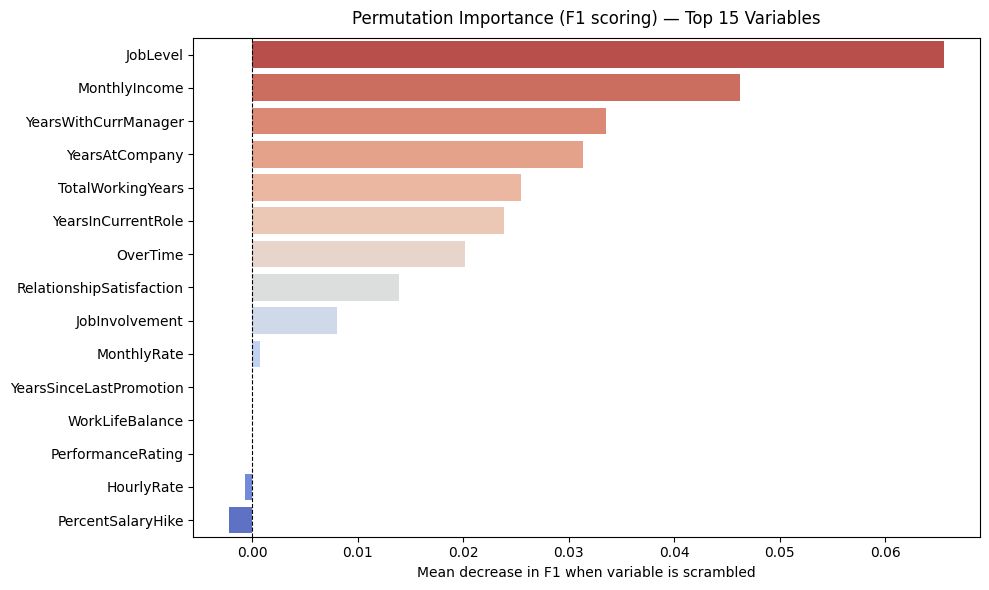

In [21]:
# Bar chart — easier to see the cliff between validated and non-validated variables

top15 = perm_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='coolwarm_r')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
                # vertical line at zero — anything to the LEFT
                # of this line had a negative permutation score
plt.title('Permutation Importance (F1 scoring) — Top 15 Variables',
          fontsize=12, pad=10)
plt.xlabel('Mean decrease in F1 when variable is scrambled')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Reading the chart:
# Top of the chart = strongest independent predictors.
# Bars to the left of zero = noise; the model worked better without them.
# The 9 validated variables all sit clearly above zero on the right.

\#\# Validated Variables — Disposition

Nine variables returned positive permutation scores\. They fall into
three thematic clusters:

\| Theme \| Variables \|
\|\-\-\-\|\-\-\-\|
\| \*\*Career stage\*\* \| JobLevel, MonthlyIncome, YearsWithCurrManager, YearsAtCompany, TotalWorkingYears, YearsInCurrentRole \|
\| \*\*Workload\*\* \| OverTime \|
\| \*\*Engagement\*\* \| RelationshipSatisfaction, JobInvolvement \|

The career stage cluster is large \(6 variables\) and these are heavily
correlated with each other\. We can't put all 6 into a regression —
they'd cannibalize each other's signal\. We need to pick representatives\.

The next two cells handle that selection: first by visualizing
the correlation matrix on just the 9 validated variables, then by
quantifying it with VIF \(Variance Inflation Factor\)\.

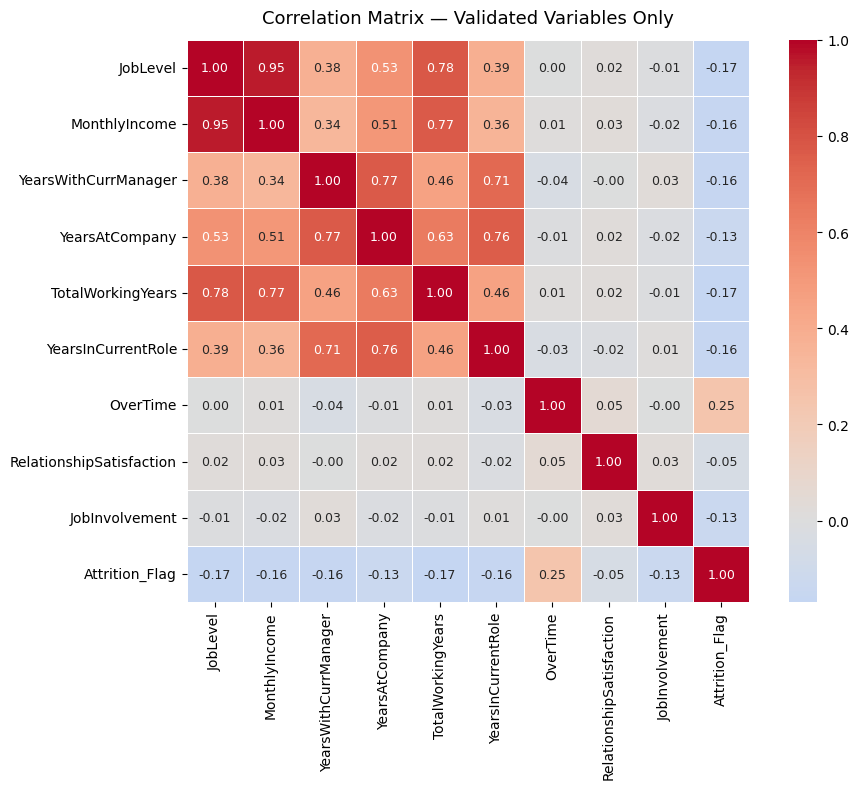

In [23]:
# Correlation matrix restricted to the 9 validated variables (+ target)
# zoomed in so we can clearly see the career stage cluster

validated_vars = [
    'JobLevel', 'MonthlyIncome', 'YearsWithCurrManager', 'YearsAtCompany',
    'TotalWorkingYears', 'YearsInCurrentRole', 'OverTime',
    'RelationshipSatisfaction', 'JobInvolvement'
]

corr_validated = df[validated_vars + ['Attrition_Flag']].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_validated,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Correlation Matrix — Validated Variables Only',
          fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# WHAT THIS SHOWS:
# - The 5x5 career-stage cluster in the top-left corner has internal
#   correlations ranging from 0.34 to 0.95.
#   JobLevel ↔ MonthlyIncome is the standout at 0.95 — they're
#   essentially the same variable wearing two hats.
# - OverTime, RelationshipSatisfaction, JobInvolvement (bottom rows)
#   show near-zero correlations with each other AND with the
#   career stage cluster. They're capturing genuinely independent signal.
# - This visual makes the variable selection problem explicit:
#   we need to collapse the career stage cluster to 1 or 2 representatives
#   and keep the 3 independent signals.

\#\# Section 4\.4 — VIF Screening

The correlation matrix shows the problem visually\. \*\*Variance Inflation
Factor \(VIF\)\*\* quantifies it\.

VIF measures how much a variable's regression coefficient is inflated
by its correlations with other variables in the model\. The decision rule:

\| VIF \| Interpretation \|
\|\-\-\-\|\-\-\-\|
\| < 5 \| Acceptable \|
\| 5 – 10 \| Moderate concern \|
\| \> 10 \| Serious multicollinearity — consider dropping \|

VIF is computed on \*\*scaled\*\* variables \(mean=0, std=1\) so the magnitudes
are comparable\. We only run it on the 9 permutation\-validated variables —
no point computing VIF for variables we've already dropped\.

In [25]:
# VIF on the validated variable set
# requires scaling so coefficients are on comparable magnitudes

X_validated = df[validated_vars].copy()
X_scaled    = pd.DataFrame(
    StandardScaler().fit_transform(X_validated),
    columns=validated_vars
)
                # StandardScaler subtracts the mean and divides by std
                # so every variable has mean=0, std=1
                # without this, VIF scores would reflect the variables'
                # raw scales rather than their actual collinearity

vif = pd.DataFrame({
    'Feature': validated_vars,
    'VIF Score': [variance_inflation_factor(X_scaled.values, i)
                  for i in range(len(validated_vars))]
}).sort_values('VIF Score', ascending=False).reset_index(drop=True)
                # variance_inflation_factor takes the full matrix
                # and the column index — computes VIF for each column

vif['VIF Score'] = vif['VIF Score'].round(2)
print("── VIF Scores (validated variables) ──\n")
print(vif.to_string(index=False))

# WHAT WE EXPECT TO SEE:
# - JobLevel and MonthlyIncome both above 10 (serious) — they correlate 0.95
# - YearsAtCompany / TotalWorkingYears / YearsWithCurrManager / YearsInCurrentRole
#   all in the 2-4 range (acceptable) but they're the career stage cluster
# - OverTime, JobInvolvement, RelationshipSatisfaction near 1.0 (clean) —
#   these are independent and will go into the model unchanged

── VIF Scores (validated variables) ──

                 Feature  VIF Score
                JobLevel      11.07
           MonthlyIncome      10.67
          YearsAtCompany       3.97
       TotalWorkingYears       3.14
    YearsWithCurrManager       2.76
      YearsInCurrentRole       2.62
          JobInvolvement       1.01
RelationshipSatisfaction       1.01
                OverTime       1.01


\#\# Final Variable Selection — Reasoning

The career stage cluster has to collapse from 6 variables to either 1 or 2\.
Here's the logic:

\| Variable \| VIF \| Decision \| Why \|
\|\-\-\-\|\-\-\-\|\-\-\-\|\-\-\-\|
\| \*\*JobLevel\*\* \| 11\.07 \| ✅ \*\*Retained\*\* \| Strongest by permutation rank \(\#1\)\. Most actionable for policy — "promote someone" is a concrete intervention\. \|
\| MonthlyIncome \| 10\.67 \| ❌ Excluded \| Correlates 0\.95 with JobLevel — same signal\. JobLevel is more actionable, so we keep it\. \|
\| TotalWorkingYears \| 3\.14 \| ❌ Excluded \| Correlates 0\.78 with JobLevel and 0\.77 with MonthlyIncome — already captured\. \|
\| YearsAtCompany \| 3\.97 \| ❌ Excluded \| Correlates 0\.77 with YearsWithCurrManager and 0\.76 with YearsInCurrentRole — overlapping signal\. \|
\| YearsWithCurrManager \| 2\.76 \| ❌ Excluded \| Captured by YearsInCurrentRole \(correlated 0\.71\)\. \|
\| \*\*YearsInCurrentRole\*\* \| 2\.62 \| ✅ \*\*Retained\*\* \| Lowest collinearity with other career stage variables in the cluster\. Captures role\-tenure signal that JobLevel alone can't\. \|
\| \*\*OverTime\*\* \| 1\.01 \| ✅ \*\*Retained\*\* \| Workload signal, completely independent\. \|
\| \*\*JobInvolvement\*\* \| 1\.01 \| ✅ \*\*Retained\*\* \| Engagement signal, completely independent\. \|
\| \*\*RelationshipSatisfaction\*\* \| 1\.01 \| ✅ \*\*Retained\*\* \| Engagement signal, completely independent\. \|

\*\*Final model variables \(5\):\*\*

1\. JobLevel \(career stage primary\)
2\. YearsInCurrentRole \(career stage secondary\)
3\. OverTime \(workload\)
4\. JobInvolvement \(engagement\)
5\. RelationshipSatisfaction \(engagement\)

These five are now ready to feed into the logistic regression model
in \*\*Notebook 4: Predictive Modeling\*\*\.

JobLevel is retained despite a VIF of 11\.07 — the conventional rule
says drop anything above 10\. The reasoning: dropping it would mean
losing the strongest single permutation predictor from the model
entirely, and the alternative \(keep MonthlyIncome instead\) sacrifices
both interpretability and policy actionability\. We carry the high VIF
forward and document it as a known limitation rather than amputating
the most important variable\.

In [27]:
# Final five features for the logistic regression model in Notebook 4

final_features = [
    'JobLevel',
    'YearsInCurrentRole',
    'OverTime',
    'JobInvolvement',
    'RelationshipSatisfaction'
]

print("Final variable selection for predictive model:")
for f in final_features:
    print(f"  - {f}")

print(f"\nTotal: {len(final_features)} variables")
print(f"\nReady for Notebook 4 (Predictive Modeling).")

Final variable selection for predictive model:
  - JobLevel
  - YearsInCurrentRole
  - OverTime
  - JobInvolvement
  - RelationshipSatisfaction

Total: 5 variables

Ready for Notebook 4 (Predictive Modeling).


\#\# Summary of Findings

The driver analysis ran two independent ranking methods \(MDI and
permutation importance\) and one collinearity check \(correlation matrix
\+ VIF\) on the same Random Forest model\. The takeaways:

1\. \*\*Nine variables emerged as validated drivers\*\* — they returned
   positive permutation scores under F1 scoring\. These cluster into
   three themes: career stage \(6 variables\), workload \(OverTime\),
   and engagement \(JobInvolvement \+ RelationshipSatisfaction\)\.

2\. \*\*MDI was misleading\.\*\* It boosted continuous variables \(DailyRate,
   HourlyRate, MonthlyIncome\) above their true contribution and missed
   JobLevel — the strongest actual driver — entirely\. Permutation
   importance corrected for this\.

3\. \*\*The career stage cluster collapsed from 6 variables to 2\*\* through
   correlation analysis and VIF screening: JobLevel \(representing the
   level/income/career\-experience axis\) and YearsInCurrentRole
   \(representing role\-specific tenure\)\.

4\. \*\*Three drivers were not in the original hypotheses:\*\* OverTime,
   RelationshipSatisfaction, and JobInvolvement\. OverTime is the most
   impactful of the three and matches the descriptive finding from
   Notebook 2 that OT workers attrite at nearly 3x the rate of non\-OT\.

The five validated variables now feed into the logistic regression
model in \*\*Notebook 4\*\*, where we'll quantify the \*direction\* and
\*magnitude\* of each driver's effect on attrition\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=01782b8c-21ad-4a9f-9322-6be507743988' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>